# Epic of Sun - Desafio 1
Training the *Attention U-Net* model.
***

This jupyter notebook trains an Attention U-Net for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the datasets in training and validation
* Build the model
* Train the model
* Evaluate the training

***

## Loading libraries and data

In [2]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from keras import layers
from keras.models import Model
#from keras.models import load_model

#import keras_tuner as kt

In [3]:
# Flags
flag_load_hyperparams = False
include_swir = False  # Set to True if you want to include SWIR bands

In [4]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [5]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [6]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting datasets in training and validation

In [7]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "attention_unet" / "attention_unet_best_hyperparams.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.00005
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 5e-05}


In [8]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [9]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto, include_swir=include_swir):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)

    # Set the shape of the tensors based on whether SWIR bands are included
    if include_swir:
        x.set_shape((128, 128, 6))  # 6 bands
    else:
        x.set_shape((128, 128, 4))  # 4 bands
    y.set_shape((128, 128, 1))

    """
     If the SWIR bands are include but you only want to use the first 4 bands 
     (Blue, Green, Red, NIR), you can slice the tensor as follows:
    # 1. Always set the shape to 6 because that is how it was saved in the TFRecord
    x.set_shape((128, 128, 6))  
    y.set_shape((128, 128, 1))
    # 2. Slice the tensor if you only want to use the first 4 bands (Blue, Green, Red, NIR)
    if not include_swir:
        x = x[..., :4]  # Keeps only channels 0, 1, 2, and 3"""

    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene, include_swir=include_swir):
    if include_swir:
        blue, green, red, nir, swir1, swir2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4], x[..., 5]
    else:
        blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    if include_swir:
        x = tf.stack([blue, green, red, nir, swir1, swir2, ndvi, ndwi, evi], axis=-1)
    else:
        x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)

    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False, include_swir=include_swir):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=2,       # fewer simultaneously-open files = less seeking
        block_length=16,      # read 16 records sequentially from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(lambda x: _parse_example(x, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(lambda x, y, scene: _add_indices(x, y, scene, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [10]:
# Create TensorFlow datasets for training, validation, and testing
# Only train and validation is going to be used in this notebook, so no test dataset is created.
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True, include_swir=include_swir)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True, include_swir=include_swir)
#test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False, include_swir=include_swir)

I0000 00:00:1787721742.616859   13974 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
#print("Testing batches:", n_test)

Training batches: 26934
Validation batches: 8978


In [12]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-08-26 02:22:32.606800: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-08-26 02:22:42.618042: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 554 of 2000
2026-08-26 02:23:00.089434: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [13]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

@tf.keras.utils.register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable()
def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [14]:
# Convolution block
# Each block performs 
# Conv -> BatchNormalization -> ReLU -> Conv -> BatchNormalization -> ReLU

def conv_block(inputs, filters, dropout=0.0):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

In [15]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [ ]:
# =============================================================================
# Attention Gate (Oktay et al., 2018 — "Attention U-Net")
#
# Idea: before concatenating a skip connection into the decoder, first ask
# "given what the decoder currently knows (g, the gating signal from the
# layer below), which spatial regions of this skip connection (x) are
# actually relevant?" The output is a soft spatial mask applied to x.
# =============================================================================

def attention_gate(x, g, inter_filters, name=""):
    """
    x: skip connection from encoder (higher resolution, e.g. 32x32)
    g: gating signal from the decoder/bottleneck (lower resolution, e.g. 16x16)
    inter_filters: number of channels in the intermediate attention computation
    """
    # Project x down to g's spatial resolution with a strided conv, so they can be added
    theta_x = layers.Conv2D(inter_filters, 1, strides=2, padding="same",
                             name=f"{name}_theta_x")(x)

    # Project g to the same channel depth (no spatial change needed, already coarse)
    phi_g = layers.Conv2D(inter_filters, 1, strides=1, padding="same",
                           name=f"{name}_phi_g")(g)

    # Combine and squash through ReLU (standard additive attention)
    add_xg = layers.Add(name=f"{name}_add")([theta_x, phi_g])
    add_xg = layers.Activation("relu", name=f"{name}_relu")(add_xg)

    # Collapse to a single-channel attention map, 0-1 via sigmoid
    psi = layers.Conv2D(1, 1, padding="same", activation="sigmoid",
                         name=f"{name}_psi")(add_xg)

    # Upsample the attention map back to x's original resolution
    psi_upsampled = layers.UpSampling2D(size=(2, 2), interpolation="bilinear",
                                         name=f"{name}_psi_upsample")(psi)

    # Apply the mask: elementwise multiply x by its own attention weights
    x_attended = layers.Multiply(name=f"{name}_gated_skip")([x, psi_upsampled])
    return x_attended

In [ ]:
# =============================================================================
# Attention-gated decoder block (replaces the plain decoder_block)
# The only change: the skip connection is passed through
# attention_gate() before concatenation.
# =============================================================================

def attention_decoder_block(inputs, skip, filters, name=""):
    # inputs = coarser decoder features = the gating signal (before upsampling)
    gated_skip = attention_gate(skip, inputs, inter_filters=filters // 2, name=f"{name}_attn")

    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same",
                                name=f"{name}_upconv")(inputs)
    x = layers.Concatenate(name=f"{name}_concat")([x, gated_skip])
    x = conv_block(x, filters)  # reusing your existing conv_block, unchanged
    return x

In [ ]:
# =============================================================================
# Full Attention U-Net — identical structure to build_unet, except the
# decoder blocks are attention-gated instead of plain.
# =============================================================================

def build_attention_unet(input_shape=(128, 128, 7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)

    # Encoder — completely unchanged from your U-Net
    s1, p1 = encoder_block(inputs, init_filters)          # 32
    s2, p2 = encoder_block(p1, init_filters * 2)          # 64
    s3, p3 = encoder_block(p2, init_filters * 4)          # 128
    s4, p4 = encoder_block(p3, init_filters * 8)          # 256

    # Bottleneck — unchanged
    b1 = conv_block(p4, init_filters * 16, dropout=0.3)   # 512

    # Decoder — now attention-gated at every skip connection
    d1 = attention_decoder_block(b1, s4, init_filters * 8, name="d1")   # 256
    d2 = attention_decoder_block(d1, s3, init_filters * 4, name="d2")   # 128
    d3 = attention_decoder_block(d2, s2, init_filters * 2, name="d3")   # 64
    d4 = attention_decoder_block(d3, s1, init_filters, name="d4")       # 32

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [19]:
# Create the model with the best hyperparameters and the right input shape based on whether SWIR bands are included or not
if include_swir:
    input_shape = (128, 128, 9)  # 6 bands + 3 indices
else:
    input_shape = (128, 128, 7)  # 4 bands + 3 indices

model = build_attention_unet(
    input_shape=input_shape,
    init_filters=saved_params["init_filters"],
    lr=saved_params["lr"],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,016 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 7,901,365 (30.14 MB)

 Trainable params: 7,895,477 (30.12 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Train the model

In [20]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "attention_unet" / "attention_unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [21]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [22]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

In [23]:
# Train the model
print("Training a new model.")
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=100,
	callbacks=[checkpoint, early_stop, reduce_lr],
	verbose=1
)
history_dict = history.history
print("Training completed.")

Training a new model.
Epoch 1/100


2026-08-26 02:23:26.252208: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1173 of 2000
2026-08-26 02:23:35.237406: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1787721815.941942   15210 service.cc:148] XLA service 0x7dc1ac004a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787721816.043683   15210 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-26 02:23:38.949650: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787721822.791900   15210 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1787721870.912040   15210 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process

421/421 ━━━━━━━━━━━━━━━━━━━━ 550s 1s/step - binary_accuracy: 0.7462 - loss: 0.4650 - precision: 0.6480 - recall: 0.8091 - val_binary_accuracy: 0.6342 - val_loss: 0.6462 - val_precision: 0.6604 - val_recall: 0.3585 - learning_rate: 5.0000e-05
Epoch 2/100


2026-08-26 02:32:27.513998: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 628 of 2000
2026-08-26 02:32:37.515725: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1839 of 2000
2026-08-26 02:32:39.104415: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - binary_accuracy: 0.8267 - loss: 0.3694 - precision: 0.7833 - recall: 0.7905

...


Epoch 31: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
421/421 ━━━━━━━━━━━━━━━━━━━━ 115s 270ms/step - binary_accuracy: 0.9010 - loss: 0.2337 - precision: 0.8854 - recall: 0.8662 - val_binary_accuracy: 0.7574 - val_loss: 0.5379 - val_precision: 0.8044 - val_recall: 0.5978 - learning_rate: 6.2500e-06
Epoch 32/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 118s 279ms/step - binary_accuracy: 0.9015 - loss: 0.2328 - precision: 0.8849 - recall: 0.8682 - val_binary_accuracy: 0.8796 - val_loss: 0.2703 - val_precision: 0.8645 - val_recall: 0.8637 - learning_rate: 3.1250e-06
Epoch 33/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - binary_accuracy: 0.9016 - loss: 0.2313 - precision: 0.8864 - recall: 0.8683

2026-08-26 03:52:24.544420: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 124s 289ms/step - binary_accuracy: 0.9023 - loss: 0.2307 - precision: 0.8859 - recall: 0.8692 - val_binary_accuracy: 0.8792 - val_loss: 0.2713 - val_precision: 0.8729 - val_recall: 0.8513 - learning_rate: 3.1250e-06
Epoch 34/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - binary_accuracy: 0.9016 - loss: 0.2313 - precision: 0.8846 - recall: 0.8707

2026-08-26 03:54:22.465219: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 129s 305ms/step - binary_accuracy: 0.9023 - loss: 0.2304 - precision: 0.8856 - recall: 0.8698 - val_binary_accuracy: 0.8784 - val_loss: 0.2737 - val_precision: 0.8751 - val_recall: 0.8463 - learning_rate: 3.1250e-06
Training completed.


In [24]:
# Save the model and its history for future use.

# Save the model in the Keras format (.keras) which includes both architecture and weights.
model_path = base_path / "models" / "attention_unet" / "attention_unet_sugarcane.keras"
model.save(str(model_path))
print(f"Model saved to '{model_path}'")

# Save the training history as a JSON file for future reference.
history_path = base_path / "models" / "attention_unet" / "attention_unet_training_history.json"
with open(str(history_path), 'w') as f:
	json.dump(history_dict, f)
print(f"Training history saved to '{history_path}'")


Model saved to '/home/fdesmello/Git/spacesugar2/models/attention_unet/attention_unet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar2/models/attention_unet/attention_unet_training_history.json'


## Evaluate the training


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/attention_unet/attention_unet_loss_accuracy.png'


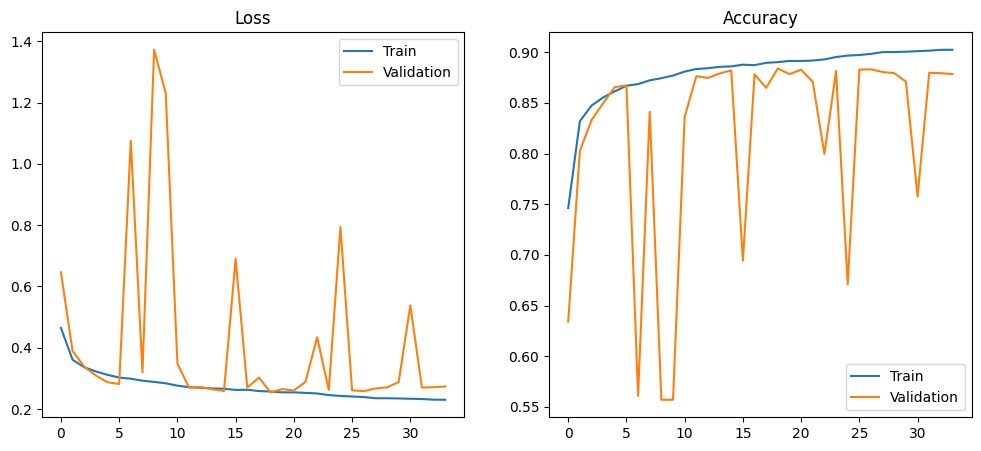

In [25]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "attention_unet" / "attention_unet_loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()